In [1]:
from medmnist import DermaMNIST
import numpy as np

train_data = DermaMNIST(split="train", download=True, size=64)
test_data  = DermaMNIST(split="test", download=True, size=64)

tr_images, tr_labels = train_data.imgs, train_data.labels
te_images, te_labels = test_data.imgs, test_data.labels

scaled_train_images = tr_images.astype("float32") / 255.0
scaled_test_images  = te_images.astype("float32") / 255.0


In [2]:
import numpy as np
import pandas as pd
import pennylane as qml
import tensorflow as tf
import time, os

def process_single_measurement_csv(scaled_images, out_dir, round_decimals=4, batch_size=1000):

    N,H,W,C = scaled_images.shape
    dev = qml.device("default.qubit.tf", wires=3)

    @qml.qnode(dev, interface="tf", diff_method=None)
    @tf.autograph.experimental.do_not_convert
    def circuit(x3):
        x3 = x3 * np.pi
        qml.AngleEmbedding(x3, wires=[0,1,2], rotation="Y")
        qml.CNOT(wires=[0,1])
        qml.CNOT(wires=[1,2])
        return qml.expval(qml.PauliZ(2))

    @tf.function
    def process_batch(b):
        return tf.vectorized_map(circuit, b)

    flat = scaled_images.reshape(-1,3)
    rounded = np.round(flat, round_decimals)
    uniq, inv = np.unique(rounded, axis=0, return_inverse=True)

    outs = []
    for i in range(0, len(uniq), batch_size):
        b = tf.convert_to_tensor(uniq[i:i+batch_size], dtype=tf.float32)
        outs.append(process_batch(b).numpy())

    uniq_vals = np.concatenate(outs, axis=0).astype(np.float32)
    all_flat = uniq_vals[inv].astype(np.float32)

    arr = all_flat.reshape(N, H, W)
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, "single_measurement.csv")
    pd.DataFrame({"val_accuracy": all_flat}).to_csv(csv_path, index=False)

    return arr, csv_path


2025-11-28 22:24:22.331353: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 22:24:22.365858: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-28 22:24:22.864616: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
train_folder = "final_new_results_single_DermaMNIST_train"
test_folder  = "final_new_results_single_DermaMNIST_test"

q_train, _ = process_single_measurement_csv(scaled_train_images, train_folder)
q_test, _  = process_single_measurement_csv(scaled_test_images , test_folder)

q_train = q_train[..., np.newaxis]   # (N,64,64,1)
q_test  = q_test[..., np.newaxis]


2025-11-28 18:11:27.801933: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
from keras import layers, models
from keras.callbacks import CSVLogger
import os, numpy as np

def run(tr_images, tr_labels, te_images, te_labels, label, out_dir):

    log_dir = os.path.join(out_dir, "run")
    os.makedirs(log_dir, exist_ok=True)

    log_file = os.path.join(log_dir, label + ".csv")
    csv_logger = CSVLogger(log_file)

    input_shape = tr_images.shape[1:]
    num_classes = len(np.unique(tr_labels))

    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        tr_images, tr_labels,
        validation_data=(te_images, te_labels),
        batch_size=128,
        epochs=5000,          
        verbose=2,
        callbacks=[csv_logger]
    )

    return model, history, log_file


In [5]:
out_dir_sm = "final_new_results_single_DermaMNIST_train"
model_sm, hist_sm, log_sm = run(q_train, tr_labels, q_test, te_labels,
                                label="single_measurement",
                                out_dir=out_dir_sm)


Epoch 1/5000


/home/aasmai/miniconda3/envs/qml_env2/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 - 2s - 33ms/step - accuracy: 0.6595 - loss: 1.1741 - val_accuracy: 0.6688 - val_loss: 1.0221
Epoch 2/5000
55/55 - 1s - 19ms/step - accuracy: 0.6695 - loss: 1.0424 - val_accuracy: 0.6743 - val_loss: 0.9485
Epoch 3/5000
55/55 - 1s - 19ms/step - accuracy: 0.6759 - loss: 0.9962 - val_accuracy: 0.6753 - val_loss: 0.9441
Epoch 4/5000
55/55 - 1s - 19ms/step - accuracy: 0.6793 - loss: 0.9490 - val_accuracy: 0.6773 - val_loss: 0.9082
Epoch 5/5000
55/55 - 1s - 19ms/step - accuracy: 0.6855 - loss: 0.9289 - val_accuracy: 0.6868 - val_loss: 0.8961
Epoch 6/5000
55/55 - 1s - 19ms/step - accuracy: 0.6902 - loss: 0.8960 - val_accuracy: 0.6943 - val_loss: 0.8838
Epoch 7/5000
55/55 - 1s - 19ms/step - accuracy: 0.6990 - loss: 0.8788 - val_accuracy: 0.6873 - val_loss: 0.8858
Epoch 8/5000
55/55 - 1s - 19ms/step - accuracy: 0.7052 - loss: 0.8464 - val_accuracy: 0.6878 - val_loss: 0.8928
Epoch 9/5000
55/55 - 1s - 19ms/step - accuracy: 0.7156 - loss: 0.8239 - val_accuracy: 0.6943 - val_loss: 0.8857
Epoch

In [6]:
tr_rgb = scaled_train_images.astype("float32")
te_rgb = scaled_test_images.astype("float32")

out_dir_nf = "final_new_results_NOFILTER_DermaMNIST"
model_nf, hist_nf, log_nf = run(tr_rgb, tr_labels, te_rgb, te_labels,
                                label="NO-FILTER",
                                out_dir=out_dir_nf)


Epoch 1/5000
55/55 - 2s - 33ms/step - accuracy: 0.6575 - loss: 1.1188 - val_accuracy: 0.6688 - val_loss: 0.9808
Epoch 2/5000
55/55 - 1s - 20ms/step - accuracy: 0.6683 - loss: 0.9826 - val_accuracy: 0.6698 - val_loss: 0.8956
Epoch 3/5000
55/55 - 1s - 20ms/step - accuracy: 0.6706 - loss: 0.9356 - val_accuracy: 0.6813 - val_loss: 0.8589
Epoch 4/5000
55/55 - 1s - 20ms/step - accuracy: 0.6776 - loss: 0.9025 - val_accuracy: 0.6783 - val_loss: 0.8362
Epoch 5/5000
55/55 - 1s - 20ms/step - accuracy: 0.6879 - loss: 0.8673 - val_accuracy: 0.6863 - val_loss: 0.7960
Epoch 6/5000
55/55 - 1s - 20ms/step - accuracy: 0.6913 - loss: 0.8297 - val_accuracy: 0.7047 - val_loss: 0.7864
Epoch 7/5000
55/55 - 1s - 20ms/step - accuracy: 0.6993 - loss: 0.8069 - val_accuracy: 0.7062 - val_loss: 0.7558
Epoch 8/5000
55/55 - 1s - 20ms/step - accuracy: 0.7057 - loss: 0.7868 - val_accuracy: 0.7047 - val_loss: 0.7641
Epoch 9/5000
55/55 - 1s - 20ms/step - accuracy: 0.7130 - loss: 0.7718 - val_accuracy: 0.7192 - val_loss:

In [7]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def metrics(model, X, y):
    preds = np.argmax(model.predict(X, verbose=0), axis=1)
    y_true = y.squeeze().astype(int)

    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average='macro')
    return acc, prec, rec, f1


In [8]:
acc_sm, prec_sm, rec_sm, f1_sm = metrics(model_sm, q_test, te_labels)


/home/aasmai/miniconda3/envs/qml_env2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [9]:
acc_nf, prec_nf, rec_nf, f1_nf = metrics(model_nf, te_rgb, te_labels)


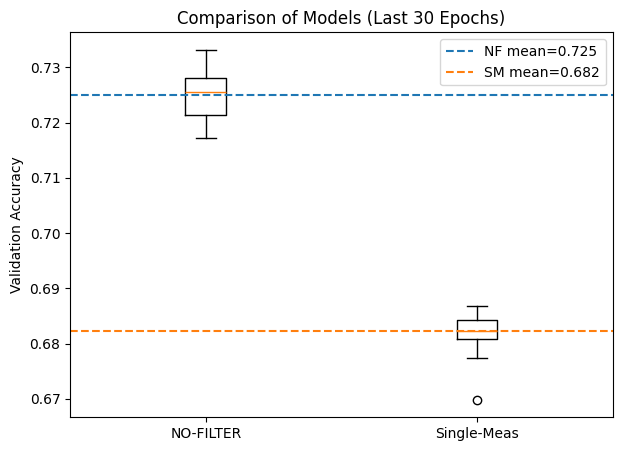

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_sm = pd.read_csv(log_sm)
df_nf = pd.read_csv(log_nf)

vals_sm = df_sm['val_accuracy'].tail(30).astype(float).tolist()
vals_nf = df_nf['val_accuracy'].tail(30).astype(float).tolist()

plt.figure(figsize=(7,5))
plt.boxplot([vals_nf, vals_sm], labels=['NO-FILTER', 'Single-Meas'])

plt.axhline(np.mean(vals_nf), color='C0', linestyle="--", label=f"NF mean={np.mean(vals_nf):.3f}")
plt.axhline(np.mean(vals_sm), color='C1', linestyle="--", label=f"SM mean={np.mean(vals_sm):.3f}")

plt.ylabel("Validation Accuracy")
plt.title("Comparison of Models (Last 30 Epochs)")
plt.legend()
plt.show()
